# Simulating iceberg "Juliette"


In [1]:
cd ~/work/tutorials/sources/OpenDrift/openberg_custom_juliette

/home/jovyan/work/tutorials/sources/OpenDrift/openberg_custom_juliette


In [2]:
from src.utils import *
from src.utils2 import *
from opendrift.models.openberg import OpenBerg
from opendrift.readers.reader_netCDF_CF_generic import Reader    
import gc

In [3]:
# --- Input data ---
wind_in = [] #choose wind input: 
#oc_in = ['topaz4','topaz5','glophyanfc','glorys'] #choose ocean sea ice and wave input, if nested list of mulitple ocean/sea ice data order by priority!
#oc_in = [[si,oc] for oc in ['topaz4','topaz5','glophyanfc','glorys'] for si in ['nextsimanfc',]] #choose ocean sea ice and wave input, if nested list of mulitple ocean/sea ice data order by priority!
# oc_in = [['topaz6-lowres','topaz5'],['nextsimanfc','topaz5'],['nextsimanfc','topaz6-lowres','topaz5']]
# oc_in = [['topaz5','mfwam'],['topaz5','waverys'],]#['glophyanfc','arcmfcwamre'],]#['topaz4','arcmfcwam'],['glorys','arcmfcwam']]
oc_in = ['arcmfcwam_vars']
# oc_in = ['arcmfcwam',]#'mfwam','waverys']

In [4]:
# --- Clean up ---
for _ in range(2):
    gc.collect()

In [5]:
# Read and subset tracker data
ds_3day = read_tracker('./input/Osker-X2.csv')['3D']
print(ds_3day.time)

<xarray.DataArray 'time' (time: 26)> Size: 208B
array(['2025-09-24T00:00:00.000000', '2025-09-27T00:00:00.000000',
       '2025-09-30T00:00:00.000000', '2025-10-03T00:00:00.000000',
       '2025-10-06T00:00:00.000000', '2025-10-09T00:00:00.000000',
       '2025-10-12T00:00:00.000000', '2025-10-15T00:00:00.000000',
       '2025-10-18T00:00:00.000000', '2025-10-21T00:00:00.000000',
       '2025-10-24T00:00:00.000000', '2025-10-27T00:00:00.000000',
       '2025-10-30T00:00:00.000000', '2025-11-02T00:00:00.000000',
       '2025-11-05T00:00:00.000000', '2025-11-08T00:00:00.000000',
       '2025-11-11T00:00:00.000000', '2025-11-14T00:00:00.000000',
       '2025-11-17T00:00:00.000000', '2025-11-20T00:00:00.000000',
       '2025-11-23T00:00:00.000000', '2025-11-26T00:00:00.000000',
       '2025-11-29T00:00:00.000000', '2025-12-02T00:00:00.000000',
       '2025-12-05T00:00:00.000000', '2025-12-08T00:00:00.000000'],
      dtype='datetime64[us]')
Coordinates:
  * time     (time) datetime64[us] 20

In [6]:
#Define index of initial simulation time steps
idx = np.arange(ds_3day.time.size) #here, 3-dayly throughout observed trajectory, ADAPT!
print(idx)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25]


In [7]:
# Dictionary of available environmental input datasets
env = {
    # --- Ocean ---
    'topaz4': 'cmems_mod_arc_phy_my_topaz4_P1D-m',
    'topaz4-ensemble':['https://thredds.met.no/thredds/dodsC/accibergt42/topaz4_be_mem0%s.ncml'%membnr for membnr in [('0'+str(memb)) 
                        if memb<10 else str(memb) for memb in range(1,11)]],
                        #find under:'https://thredds.met.no/thredds/catalog/accibergt42/catalog.html',
    'topaz5': 'cmems_mod_arc_phy_anfc_6km_detided_PT1H-i',
    'topaz5-ensemble': ['https://thredds.met.no/thredds/dodsC/accibergt5/topaz5_be_mem0%s.ncml'%membnr for membnr in [('0'+str(memb)) 
                        if memb<10 else str(memb) for memb in range(1,11)]],                      
                       #find under: https://thredds.met.no/thredds/catalog/accibergt5/catalog.html',
    'topaz6': 'https://thredds.met.no/thredds/dodsC/cmems/topaz6/dataset-topaz6-arc-15min-3km-be.ncml', 
    'topaz6-lowres': 'dataset-topaz6-arc-15min-3km-be',
    'glophyanfc': 'cmems_mod_glo_phy_anfc_0.083deg_PT1H-m', #Global anfc (mercator)
    'glorys': 'cmems_mod_glo_phy_my_0.083deg_P1D-m',
    # --- Sea ice ---
    'nextsimanfc':'cmems_mod_arc_phy_anfc_nextsim_hm',
    'nextsimre':'cmems_mod_arc_phy_my_nextsim_P1D-m',
    # --- Wave ---
    'arcmfcwam':'dataset-wam-arctic-1hr3km-be',
    'arcmfcwam_vars':{'id':"dataset-wam-arctic-1hr3km-be",'variables':["VHM0","VMDR","VSDX","VSDY"]},
    'arcmfcwamre':'cmems_mod_arc_wav_my_3km_PT1H-i',
    'mfwam':'cmems_mod_glo_wav_anfc_0.083deg_PT3H-i',
    'waverys':'cmems_mod_glo_wav_my_0.2deg_PT3H-i',
    # --- Wind ---
    'windglophyre':'cmems_obs-wind_glo_phy_my_l4_0.125deg_PT1H', #availability; 2007-2026
    'windglophynrt':'cmems_obs-wind_glo_phy_nrt_l4_0.125deg_PT1H', #availability: 2024-2026
    'era5':'./input/era5_juliette.nc',
    'carra2': 'input/carra2_juliette.grib'} #Has to be downloaded

In [8]:
#---Combintaions of inputs
if np.logical_and(wind_in!=[],oc_in!=[]): input_l = [(oc if isinstance(oc, list) else [oc]) + [wi] for wi in wind_in for oc in oc_in ] 
elif np.logical_and(wind_in==[],oc_in!=[]): input_l = [(oc if isinstance(oc, list) else [oc]) for oc in oc_in]
elif np.logical_and(wind_in!=[],oc_in==[]): input_l = [(wi if isinstance(wi, list) else [wi]) for wi in wind_in]
else: print('Provide input data!')
# --- Show configurations ---
print("\nAvailable forcing configurations:")
for i, envinput in enumerate(input_l):
    print(i, envinput)


Available forcing configurations:
0 ['arcmfcwam_vars']


In [9]:
# --- Simulation definitions ---
ib_duration = 3 #in days, How long every iceberg is simulated after its individual initialisation (iceberg age)
n=10 #number of icebergs released on every initialisation

# --- Randomisation
# rng = np.random.default_rng(42)  # "seed" random drawing so it is the same for every simulation
# randspace = rng.random(n)
randspace = np.linspace(0,1,n) #uniformly distributed instead of random

# --- Initial iceberg conditions ---
#---Trajectory information---
lons = ds_3day.lon[idx]
lats = ds_3day.lat[idx]
times = pd.to_datetime(ds_3day.time[idx].values).to_pydatetime().tolist()#[t.values.astype(datetime) for t in ds_3day.time[idx]]

#---Iceberg size---
#iceberg = {'length':150+randspace*100,'width':80+randspace*10, 
 #       'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1} #Randomised sizes and coefficients
#iceberg = {'length':[50,2000,500,1000,2000], 
#       'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1} #hardcoded input size
# iceberg = {'length':50+randspace*2000, #meassured and random sizes
#        'water_form_drag_coef':0.25+randspace*1.25,'wind_form_drag_coef':0.5+randspace*1, #Randomised sizes and coefficients
#            'radius':500}
#randdim= np.random.rand(n) * 0.1 + 0.955 #for 10% variation
randlength = np.sort(randspace*2000+50) #random in defined range, here 50 to 2000m
randcoefwa = randspace*1.25+0.25
randcoefwi = randspace*1+0.5
iceberg = {'length': randlength, 
           'water_form_drag_coef': randcoefwa, 'wind_form_drag_coef': randcoefwi,
           'radius':1000}
#---Size correction---
iceberg = calc_iceberg_size(iceberg) #this function adds missing iceberg sizes
idx0 = 0 #np.arange(0,n*idx.size,n)+1 #identity of  "member" that should contain observed size for every time-position-intitialisation, here the second
iceberg['length'][idx0] = 200 #correct for meassured width
iceberg['width'][idx0] = 85 #correct for meassured width
# print(iceberg)


In [10]:
# members = np.arange(10)
# ds_env = xr.open_mfdataset(env['topaz4-ensemble'],
#             concat_dim=xr.DataArray(members, dims='member', name='member',
#             attrs={'standard_name': 'realization'}),
#             combine='nested', data_vars='all', coords='all', chunks={'time': 1}) #Solution from KF!

In [11]:
# ds_env = xr.open_mfdataset(env['topaz4-ensemble'],
#          combine="nested",
#          concat_dim="realization",#should be named "realization" or "ensemble_member"
#          parallel=True,engine="netcdf4", chunks={'time': 10})
# ds_env = ds_env.assign_coords(realization=xr.DataArray(ds_env.realization,dims=("realization",),
#     attrs={"standard_name": "realization","long_name": "ensemble member","axis": "E"}))

In [12]:
# ds_env.time


Running with inputs: ['arcmfcwam_vars']
Loading dataset: {'id': 'dataset-wam-arctic-1hr3km-be', 'variables': ['VHM0', 'VMDR', 'VSDX', 'VSDY']}


INFO - 2026-06-18T19:50:44Z - Selected dataset version: "202411"
INFO - 2026-06-18T19:50:44Z - Selected dataset part: "default"


❌ Failed to load {'id': 'dataset-wam-arctic-1hr3km-be', 'variables': ['VHM0', 'VMDR', 'VSDX', 'VSDY']}: Dimensions {np.str_('VSDY'), np.str_('VMDR'), np.str_('VHM0'), np.str_('VSDX')} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'time': 2905, 'lat': 334, 'lon': 1000})
<xarray.Dataset> Size: 82MB
Dimensions:                                   (trajectory: 260, time: 1872)
Coordinates:
  * trajectory                                (trajectory) int32 1kB 0 1 ... 259
  * time                                      (time) datetime64[ns] 15kB 2025...
Data variables: (12/39)
    status                                    (trajectory, time) float64 4MB ...
    moving                                    (trajectory, time) float64 4MB ...
    age_seconds                               (trajectory, time) float32 2MB ...
    origin_marker                             (trajectory, time) float64 4MB ...
    lon                                       (trajectory, time) float32 2M

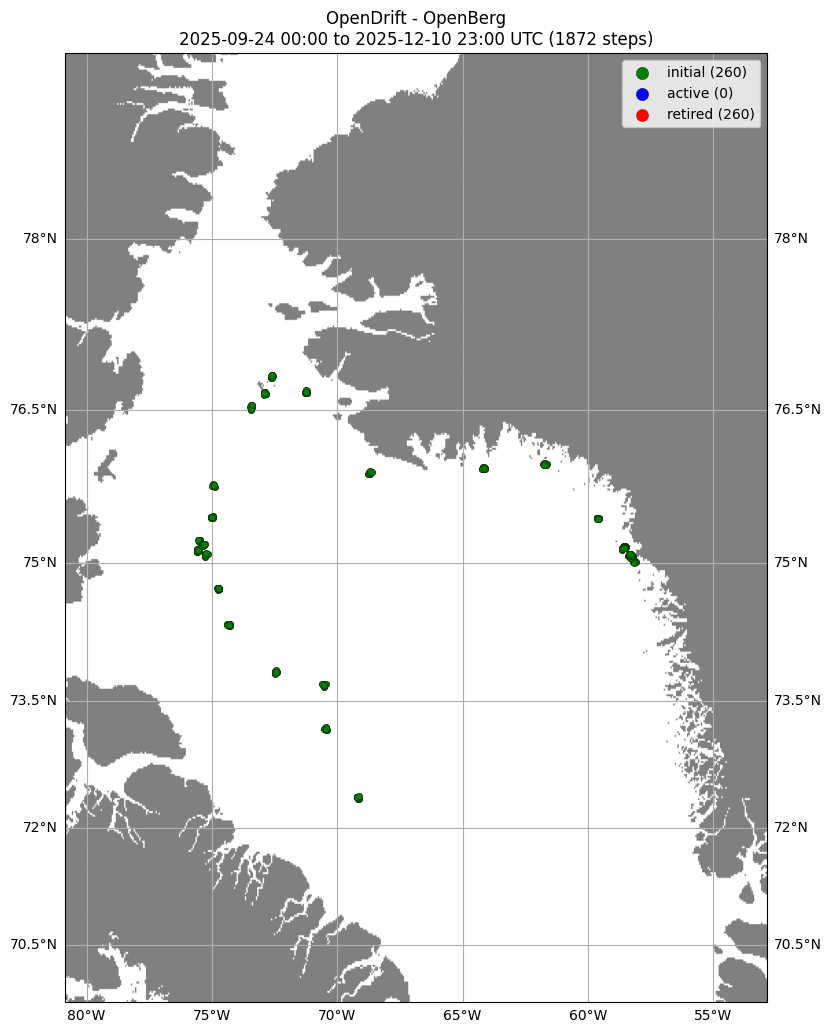

In [16]:
# --- Runs simulations
for envinput in input_l: #Loops through the ocean and wind input
    print(f"\nRunning with inputs: {envinput}")
    #---Initialisation---
    o=OpenBerg(loglevel=10,logfile='./results/out_%s.log'%('_'.join(envinput)))
    #---Model configuration---
    o.set_config('drift:max_age_seconds', ib_duration*3600*24) #Terminates simulations  ib_duration seconds after their individual initialisation
    o.set_config('drift:vertical_profile',False)
    o.set_config('drift:stokes_drift',False)
    o.set_config('drift:wave_rad',False)
    o.set_config('drift:wind_drag',True)
    o.set_config('drift:sea_ice_drag',False)
    #---Readers
    for envin in envinput:
        dataset_id = env[envin]
        print(f"Loading dataset: {dataset_id}")
        try:
            if 'vars' in envin: #lload only custom variables of dataset
                ds_env=read_cmems_custom_variables(dataset_id['id'],dataset_id['variables'])
                reader_env = Reader(ds_env[ds_env],name=envin)
                o.add_reader(reader_env)                    
            elif isinstance(dataset_id, str) and dataset_id.endswith('.nc'): #local files, e.g. era5
                mapping_dict = {}
                ds_env = xr.open_mfdataset(dataset_id)
                if 'era5' in dataset_id:
                    ds_env = ds_env.chunk({"valid_time": 1})
                    mapping_dict['standard_name_mapping']={'u10': 'x_wind','v10': 'y_wind'}
                if 'ensemble' not in dataset_id: ds_env = ds_env.drop_vars(['number','expver']) #if not ensemble
                if 'carra' in dataset_id: 
                    ds_env['longitude'] = ds_env['longitude'] - 360
                    mapping_dict['standard_name_mapping']={'u10': 'x_wind','v10': 'y_wind'}
                reader_env = Reader(ds_env,**mapping_dict)
                o.add_reader(reader_env)
            elif isinstance(dataset_id, list) and 'ensemble' in envin: #list of urls or files, eg. for topaz4 ensemble
                # ds_env = xr.open_mfdataset(dataset_id,
                #          combine="nested",
                #          concat_dim="realization",#should be named "realization" or "ensemble_member"
                #          parallel=True,engine="netcdf4", chunks={'time': 1})
                # ds_env = ds_env.assign_coords(realization=xr.DataArray(ds_env.realization,dims=("realization",),
                #     attrs={"standard_name": "realization","long_name": "ensemble member","axis": "E"}))
                # ds_env = xr.open_mfdataset(
                #     dataset_id,
                #     combine="nested",
                #     concat_dim="realization",
                #     coords="minimal",
                #     compat="override",
                #     parallel=True,
                #     engine="netcdf4",
                #     chunks={'time': -1}
                # )
                # ds_env = ds_env.assign_coords(
                #     realization=np.arange(ds_env.sizes["realization"])
                # )
                members = np.arange(len(dataset_id))
                ds_env = xr.open_mfdataset(dataset_id,
                            concat_dim=xr.DataArray(members, dims='member', name='member',
                            attrs={'standard_name': 'realization'}),
                            combine='nested', data_vars='all', coords='all', chunks={'time': 1}) #Solution from KF! does not work yet
                reader_env = Reader(ds_env,name='Ensemble reader')
                o.add_reader(reader_env)
            else: o.add_readers_from_list([dataset_id]) 
        except Exception as e:
            print(f"❌ Failed to load {dataset_id}: {e}")
    #---Seed icebergs---
    for lon, lat, time in zip(lons, lats, times): #Loops through initialisations of time-positions
        o.seed_elements(
            lon=lon,
            lat=lat,
            time=time,
            number=n,
            **iceberg)
    #---Run---
    oi = o.run(duration=timedelta(days=int(idx.size*ib_duration)), #duration from first initialisation to last termination not equal to ib age!
               outfile='./results/juliette_%s.nc'%('_'.join(envinput)))
    #---Plot map---
    o.plot(fast=True,filename='./results/juliette_map_%s.png'%('_'.join(envinput)))
    #collect left over data
    for _ in range(2):
        gc.collect()
print(oi)

In [14]:
ds_env

<xarray.Dataset> Size: 16GB
Dimensions:  (time: 2905, lat: 334, lon: 1000)
Coordinates:
  * time     (time) datetime64[ns] 23kB 2025-09-01 ... 2025-12-31
  * lat      (lat) float64 3kB 70.0 70.03 70.06 70.09 ... 79.91 79.94 79.97 80.0
  * lon      (lon) float64 8kB -80.0 -79.97 -79.94 ... -50.09 -50.06 -50.03
Data variables:
    VHM0     (time, lat, lon) float32 4GB dask.array<chunksize=(2040, 64, 1000), meta=np.ndarray>
    VMDR     (time, lat, lon) float32 4GB dask.array<chunksize=(2040, 64, 1000), meta=np.ndarray>
    VSDX     (time, lat, lon) float32 4GB dask.array<chunksize=(2040, 64, 1000), meta=np.ndarray>
    VSDY     (time, lat, lon) float32 4GB dask.array<chunksize=(2040, 64, 1000), meta=np.ndarray>
Attributes:
    copernicusmarine_version:  2.4.1

In [15]:
#Some checks# print('Occuring stati',np.unique(oi.status))
#print('proportion of trajectories that became stranded (at any time)',np.mean(np.any(oi.status==1,axis=1)).values)
#print('proportion of trajectories that are stranded (at the end of simulations)',np.mean(oi.status[:,-1]==1).values)
#print('proportion of trajectories that meltet',np.mean(np.any(oi.status==2,axis=1)).values)
#print('which size do melted trajectories have??',oi.sail[np.any(oi.status==2,axis=1),0].values)
# print('proportion of trajectories that are active (ever)', 
#       np.mean(np.any(oi.status == 0, axis=1)))
# print('proportion of trajectories that are active at the end', 
#       np.mean(oi.status[:, -1] == 0))
# print('proportion of trajectories that melted', 
#       np.mean(np.any(oi.status == 2, axis=1)))

#o.plot_property('sea_surface_wave_significant_height')#,filename='../results/juliette_property.png')
#other usedfull properties to plot: draft, sail, length, width, status, x_Wind

# Regularely do in terminal:
# - processes: ps aux | grep python
# - kill kernels (too many open kernels are a problem): pkill -f ipykernel
# - or check kernels: ps aux | grep ipykernel
# - and kill individual ones: kill -9 2260
# - but then they will restart automatically, instead use taskline-Kernels-Shut down all Kernels! Works only 1 kernel left